# 02 — Feature Engineering
**Training snapshot:** Day 42 (week 6). All behavioral features computed from `date ≤ 42`.  
**Output:** `data/processed/feature_matrix.csv` and `data/processed/labels.csv`

### Feature Groups
| Group | Features |
|-------|----------|
| VLE behavioral | total_clicks_w6, pre_course_clicks, vle_rolling_w6/w4, vle_delta_wow, days_since_last_vle, active_days_w6, recent_silence_flag |
| Assessment behavioral | submission_count_w6, submission_rate_w6/w4, submission_delta, avg_score_w6, gpa_trend, early_submission_days |
| Demographic + static | gender_M, disability_Y, imd_band_num, imd_band_missing, age_band_num, edu_num, num_of_prev_attempts, studied_credits, days_since_registration, region dummies |
| Synthetic | financial_hold_flag, credit_load, credit_overload_flag |

**Note on submission_rate:** Most assessments are due after day 42 (median due date ~day 105). Denominator = total non-exam assessments in module, not assessments due by day 42. Module GGG's first TMA is due day 61, so most GGG students have submission_rate_w6 ≈ 0 — VLE features carry the signal for GGG.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.features import build_feature_matrix, KEY_COLS

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Build Feature Matrix

In [2]:
X, y = build_feature_matrix(
    data_dir='../data/raw',
    synth_dir='../data/synthetic',
    save_dir='../data/processed',
)
print(f'\nFeatures: {list(X.columns)}')

Loading data...


Computing VLE features...
Computing assessment features...


Computing demographic features...
Merging...

Feature matrix: 32,593 rows × 39 features
Label: 10,156 withdrawn / 22,437 retained (31.2% positive)


Saved to ..\data\processed/

Features: ['total_clicks_w6', 'active_days_w6', 'pre_course_clicks', 'vle_rolling_w6', 'vle_rolling_w4', 'days_since_last_vle', 'recent_silence_flag', 'vle_delta_wow', 'submission_count_w6', 'submission_rate_w6', 'submission_rate_w4', 'submission_delta', 'avg_score_w6', 'gpa_trend', 'early_submission_days', 'num_of_prev_attempts', 'studied_credits', 'gender_M', 'disability_Y', 'imd_band_missing', 'imd_band_num', 'age_band_num', 'edu_num', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'days_since_registration', 'financial_hold_flag', 'credit_load', 'credit_overload_flag']


## Feature Matrix Health Check

In [3]:
print('=== Shape ===')
print(f'X: {X.shape}  |  y: {y.shape}')
print(f'Positive class (withdrawn): {y.sum():,} ({y.mean()*100:.1f}%)')
print()

print('=== Null counts ===')
nulls = X.isnull().sum()
if nulls.sum() == 0:
    print('No nulls — feature matrix is complete.')
else:
    print(nulls[nulls > 0])
print()

print('=== Dtypes ===')
print(X.dtypes.value_counts())
print()

print('=== Descriptive statistics (numeric features) ===')
display(X.describe().T)

=== Shape ===
X: (32593, 39)  |  y: (32593,)
Positive class (withdrawn): 10,156 (31.2%)

=== Null counts ===
No nulls — feature matrix is complete.

=== Dtypes ===
int8       20
float32    11
float64     6
int16       2
Name: count, dtype: int64

=== Descriptive statistics (numeric features) ===


,count,mean,std,min,25%,50%,75%,max
total_clicks_w6,32593.0,326.957046,437.323340,0.000000,44.000000,188.000000,439.000000,8307.000000
active_days_w6,32593.0,13.585064,11.177741,0.000000,4.000000,12.000000,21.000000,43.000000
pre_course_clicks,32593.0,65.127880,129.225743,0.000000,0.000000,18.000000,75.000000,3731.000000
vle_rolling_w6,32593.0,37.563741,69.981457,0.000000,0.000000,8.000000,46.000000,1274.000000
vle_rolling_w4,32593.0,49.943117,87.677594,0.000000,0.000000,15.000000,64.000000,2306.000000
days_since_last_vle,32593.0,11.238548,14.940962,0.000000,1.000000,3.000000,17.000000,42.000000
recent_silence_flag,32593.0,0.270580,0.444266,0.000000,0.000000,0.000000,1.000000,1.000000
vle_delta_wow,32593.0,2.395233,13.714525,-0.998516,-0.666667,0.000000,0.250000,492.000000
submission_count_w6,32593.0,1.040929,0.907771,0.000000,0.000000,1.000000,2.000000,12.000000
submission_rate_w6,32593.0,0.129451,0.111126,0.000000,0.000000,0.125000,0.200000,1.000000


## Feature–Target Correlation

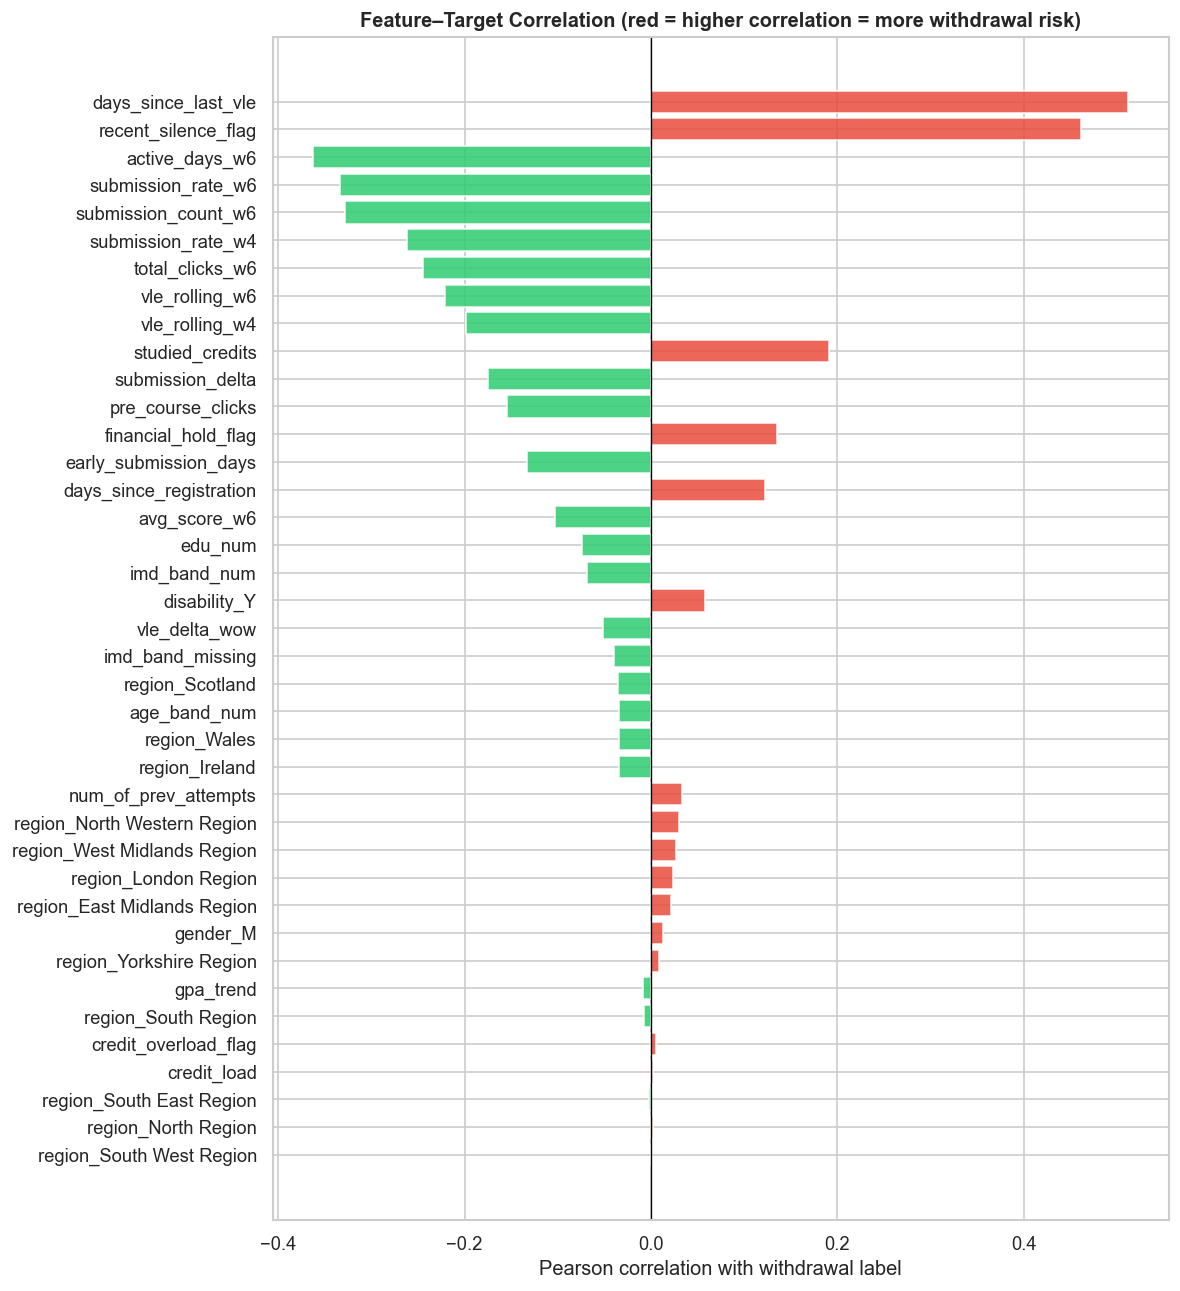

Top 10 features by absolute correlation with withdrawal:
days_since_last_vle    0.5121
recent_silence_flag    0.4618
active_days_w6        -0.3623
submission_rate_w6    -0.3337
submission_count_w6   -0.3280
submission_rate_w4    -0.2617
total_clicks_w6       -0.2450
vle_rolling_w6        -0.2211
vle_rolling_w4        -0.1984
studied_credits        0.1912


In [4]:
# Point-biserial correlation with binary label (equivalent to Pearson for binary target)
corr = X.corrwith(y.astype(float)).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(corr) * 0.28)))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with withdrawal label')
ax.set_title('Feature–Target Correlation (red = higher correlation = more withdrawal risk)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by absolute correlation with withdrawal:')
print(corr.head(10).round(4).to_string())

## VLE Feature Distributions by Label

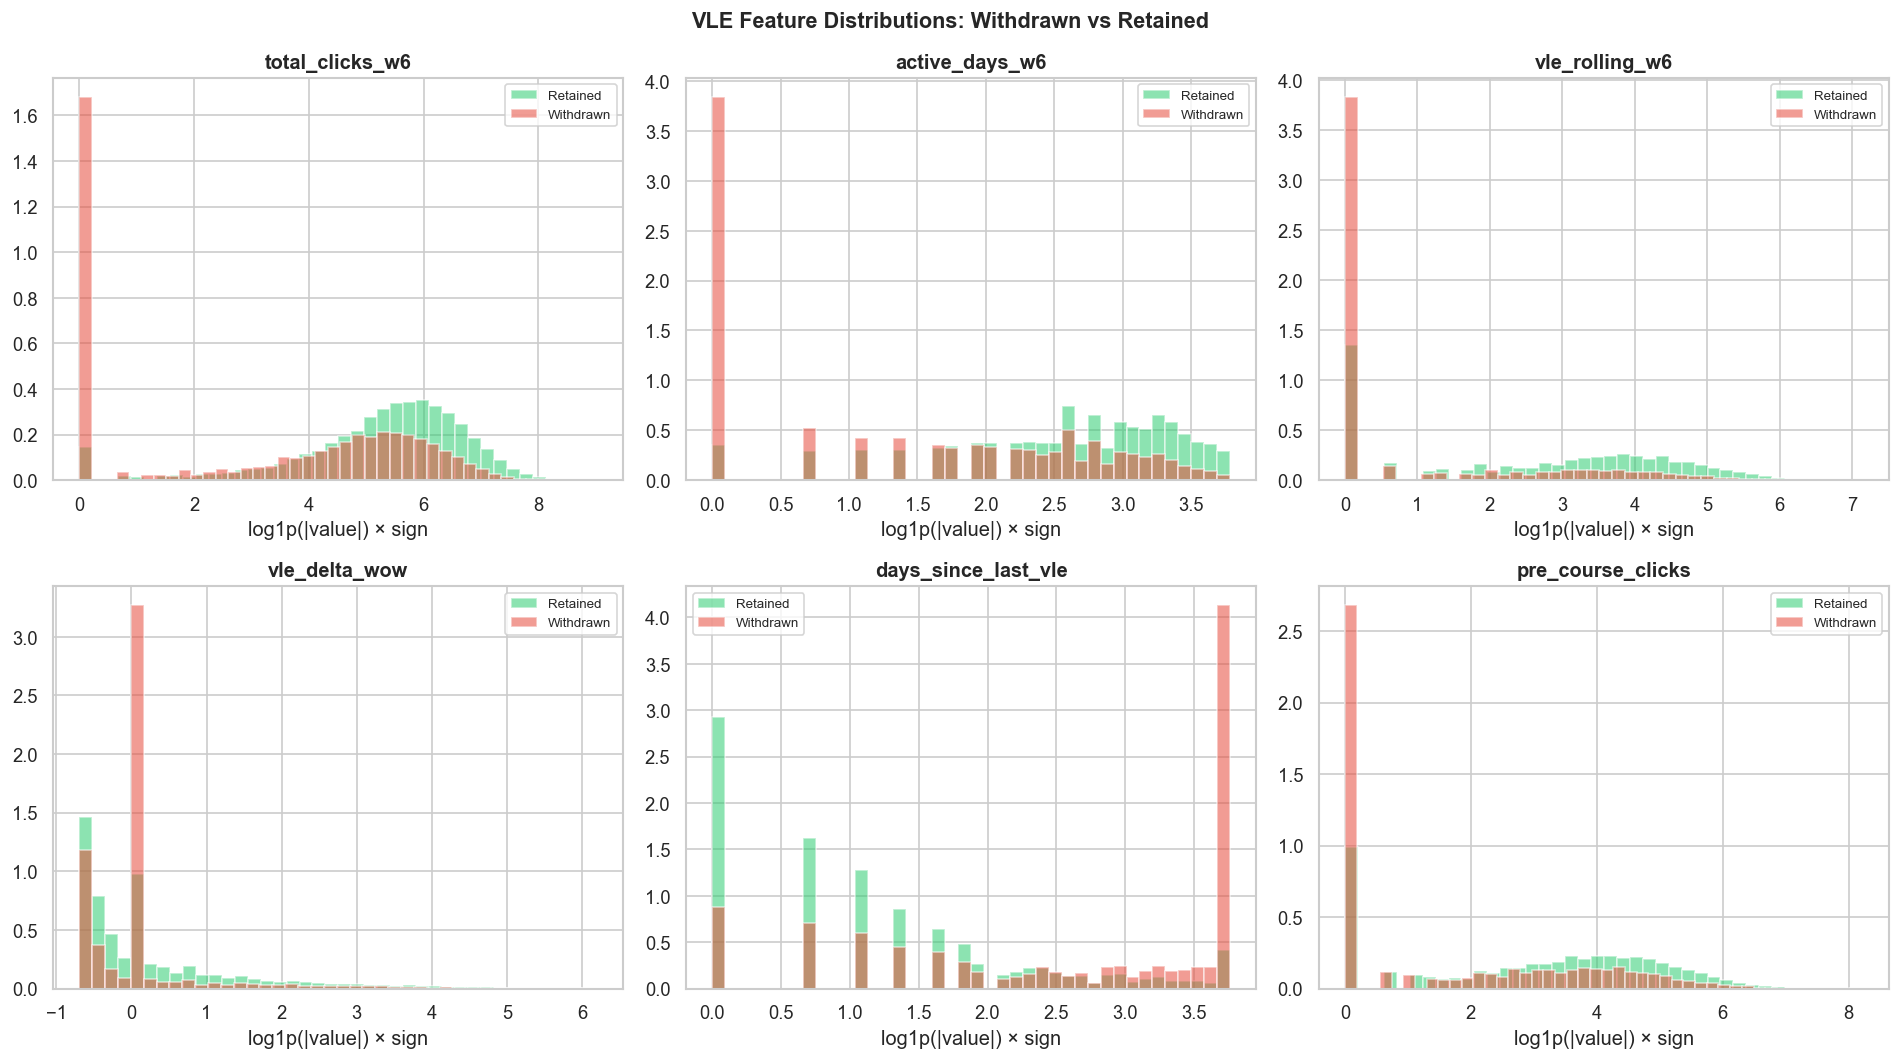

In [5]:
vle_features = ['total_clicks_w6', 'active_days_w6', 'vle_rolling_w6',
                'vle_delta_wow', 'days_since_last_vle', 'pre_course_clicks']

Xy = X.copy()
Xy['label'] = y

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), vle_features):
    for lv, name, color in [(0, 'Retained', '#2ecc71'), (1, 'Withdrawn', '#e74c3c')]:
        vals = Xy[Xy['label'] == lv][col].values
        ax.hist(np.log1p(np.abs(vals)) * np.sign(vals), bins=40,
                alpha=0.55, label=name, color=color, density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('log1p(|value|) × sign')
    ax.legend(fontsize=8)

plt.suptitle('VLE Feature Distributions: Withdrawn vs Retained', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vle_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Assessment Feature Distributions by Label

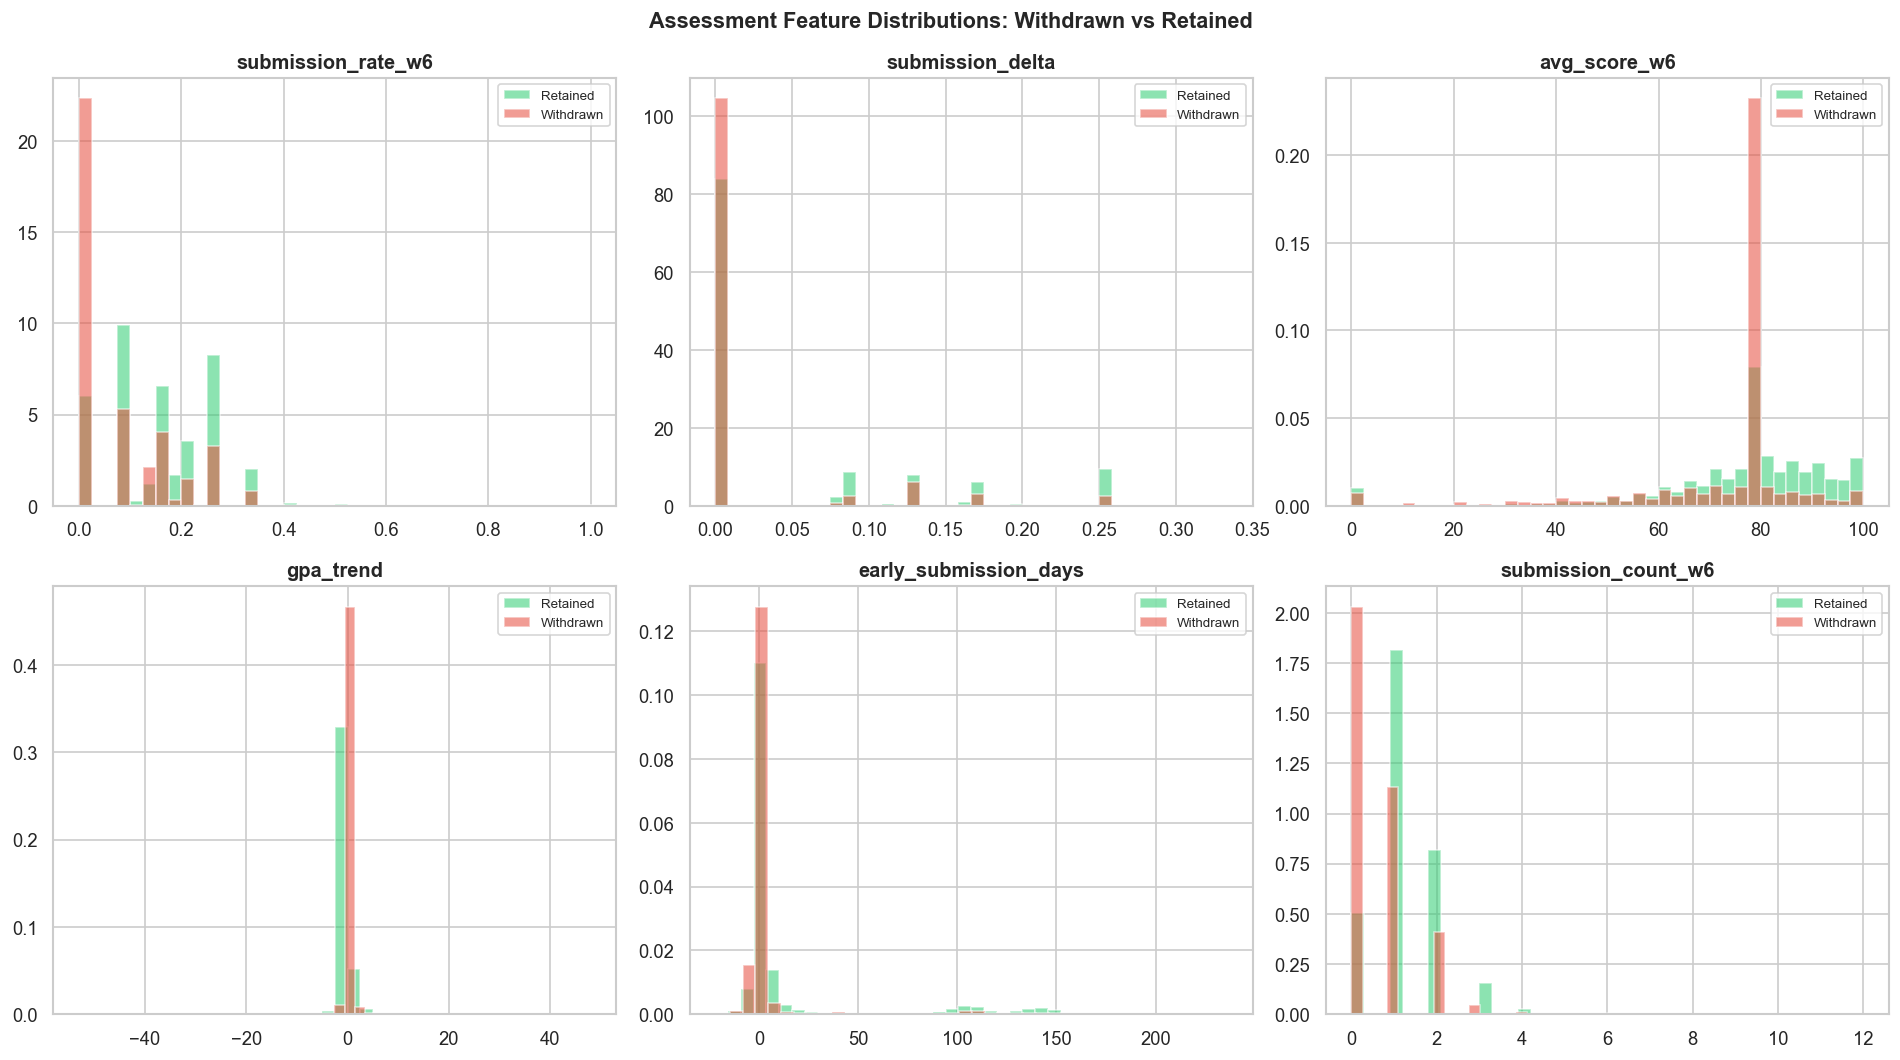

In [6]:
assess_features = ['submission_rate_w6', 'submission_delta', 'avg_score_w6',
                   'gpa_trend', 'early_submission_days', 'submission_count_w6']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), assess_features):
    for lv, name, color in [(0, 'Retained', '#2ecc71'), (1, 'Withdrawn', '#e74c3c')]:
        vals = Xy[Xy['label'] == lv][col].dropna().values
        ax.hist(vals, bins=40, alpha=0.55, label=name, color=color, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Assessment Feature Distributions: Withdrawn vs Retained', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'assessment_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Withdrawal Rate by Binary Synthetic Features

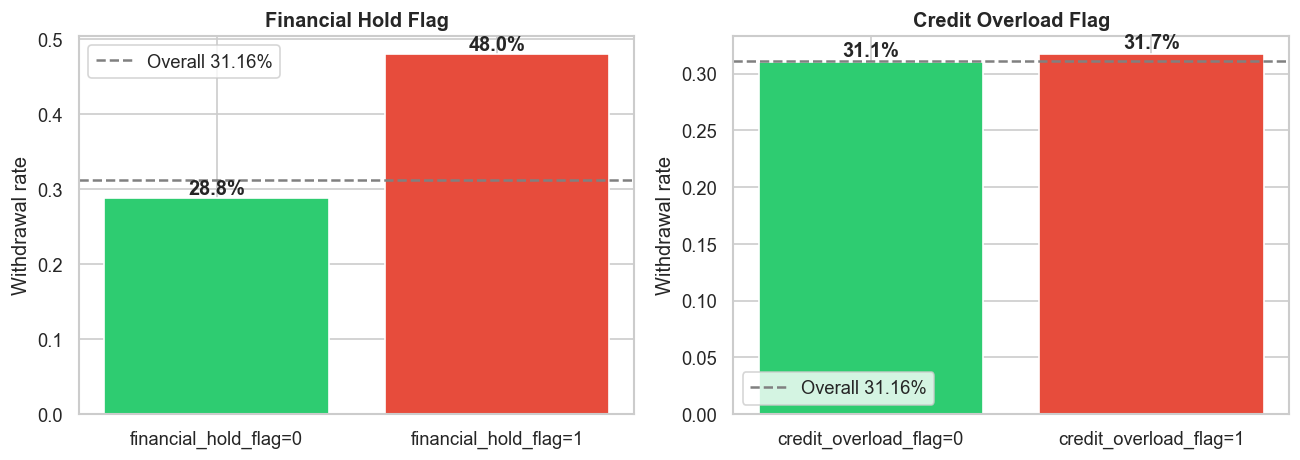

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label in [
    (axes[0], 'financial_hold_flag', 'Financial Hold Flag'),
    (axes[1], 'credit_overload_flag', 'Credit Overload Flag'),
]:
    rates = Xy.groupby(col)['label'].mean()
    ax.bar([f'{col}=0', f'{col}=1'], rates.values,
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.axhline(y.mean(), color='gray', linestyle='--', label=f'Overall {y.mean():.2%}')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Withdrawal rate')
    ax.legend()
    for i, rate in enumerate(rates.values):
        ax.text(i, rate + 0.005, f'{rate:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'synthetic_feature_signal.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Summary

In [8]:
print(f'Total features: {X.shape[1]}')
print(f'Total rows (student-module pairs): {X.shape[0]:,}')
print()

# Group features by type
vle_cols    = [c for c in X.columns if any(x in c for x in ['vle', 'click', 'active_days', 'silence', 'pre_course'])]
assess_cols = [c for c in X.columns if any(x in c for x in ['submission', 'score', 'gpa', 'early'])]
region_cols = [c for c in X.columns if c.startswith('region_')]
other_cols  = [c for c in X.columns if c not in vle_cols + assess_cols + region_cols]

print(f'VLE behavioral ({len(vle_cols)}):    {vle_cols}')
print(f'Assessment ({len(assess_cols)}):       {assess_cols}')
print(f'Region dummies ({len(region_cols)}):   {region_cols}')
print(f'Demographic/synthetic ({len(other_cols)}): {other_cols}')
print()
print('Phase 2 complete. Ready for Phase 3: Model Development.')
print(f"feature_matrix.csv → data/processed/ ({X.shape[0]:,} rows × {X.shape[1]} cols)")
print(f"labels.csv         → data/processed/ ({y.sum():,} positive, {(y==0).sum():,} negative)")

Total features: 39
Total rows (student-module pairs): 32,593

VLE behavioral (8):    ['total_clicks_w6', 'active_days_w6', 'pre_course_clicks', 'vle_rolling_w6', 'vle_rolling_w4', 'days_since_last_vle', 'recent_silence_flag', 'vle_delta_wow']
Assessment (7):       ['submission_count_w6', 'submission_rate_w6', 'submission_rate_w4', 'submission_delta', 'avg_score_w6', 'gpa_trend', 'early_submission_days']
Region dummies (12):   ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']
Demographic/synthetic (12): ['num_of_prev_attempts', 'studied_credits', 'gender_M', 'disability_Y', 'imd_band_missing', 'imd_band_num', 'age_band_num', 'edu_num', 'days_since_registration', 'financial_hold_flag', 'credit_load', 'credit_overload_flag']

Phase 2 complete.